### Installing Libraries

In [ ]:
!pip install tensorflow==2.10.0 tensorflow-io==0.27.0

  Using cached tensorflow-2.10.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (578.0 MB)
  Using cached keras-2.10.0-py2.py3-none-any.whl (1.7 MB)
  Using cached tensorboard-2.10.1-py3-none-any.whl (5.9 MB)
  Using cached tensorflow_estimator-2.10.0-py2.py3-none-any.whl (438 kB)
  Attempting uninstall: keras
    Found existing installation: keras 2.9.0
    Uninstalling keras-2.9.0:
      Successfully uninstalled keras-2.9.0
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 1.12
    Uninstalling flatbuffers-1.12:
      Successfully uninstalled flatbuffers-1.12
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.9.0
    Uninstalling tensorflow-estimator-2.9.0:
      Successfully uninstalled tensorflow-estimator-2.9.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.9.1
    Uninstalling tensorboard-2.9.1:
      Successfully uninstalled tensorboard-2.9.1
  Attempt

In [ ]:
# !pip uninstall tensorflow --yes
# !pip uninstall tensorflow_io --yes

# !pip install tensorflow==2.10.0 tensorflow-io==0.27.0
!pip install tensorflow-gpu
!pip install --no-deps tensorflow_io
!pip install -q -U tensorflow-addons
# !pip install tensorflow
# !pip install tensorflow-io
!pip install tensorflow-addons
# !pip install gdown

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 7.5 MB/s eta 0:00:00


In [ ]:
# Run this cell to solve DNN error

!apt-cache policy libcudnn8

# Install latest version
!apt install --allow-change-held-packages libcudnn8=8.4.1.50-1+cuda11.6

# Export env variables
!export PATH=/usr/local/cuda-11.4/bin${PATH:+:${PATH}}
!export LD_LIBRARY_PATH=/usr/local/cuda-11.4/lib64:$LD_LIBRARY_PATH
!export LD_LIBRARY_PATH=/usr/local/cuda-11.4/include:$LD_LIBRARY_PATH
!export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/usr/local/cuda/extras/CUPTI/lib64

# Install tensorflow
!pip install tflite-model-maker==0.4.0
!pip uninstall -y tensorflow && pip install -q tensorflow==2.9.1
!pip install pycocotools==2.0.4
!pip install opencv-python-headless==4.6.0.66

libcudnn8:
  Installed: 8.9.6.50-1+cuda12.2
  Candidate: 8.9.7.29-1+cuda12.2
  Version table:
     8.9.7.29-1+cuda12.2 600
        600 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages
     8.9.7.29-1+cuda11.8 600
        600 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages
 *** 8.9.6.50-1+cuda12.2 600
        600 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages
        100 /var/lib/dpkg/status
     8.9.6.50-1+cuda11.8 600
        600 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages
     8.9.5.30-1+cuda12.2 600
        600 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages
     8.9.5.30-1+cuda11.8 600
        600 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages
     8.9.5.29-1+cuda12.2 600
        600 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  

### Importing Libraries

In [ ]:
import sys
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
%matplotlib inline

import cv2
import time
import itertools
import random

from sklearn.utils import shuffle

from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.layers import Conv2D, ZeroPadding2D, Activation, Input, concatenate, Dropout
from tensorflow.keras.models import Model

from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.layers import Lambda, Flatten, Dense
from tensorflow.keras.initializers import glorot_uniform
import tensorflow_io as tfio
from tensorflow.keras.applications import resnet
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model

import matplotlib.image as mpimg
from tensorflow.keras import applications
from tensorflow.keras import metrics
import tensorflow_addons as tfa

from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import datetime
import warnings
import matplotlib.image as mpimg
from functools import reduce
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

## Download Dataset:

- First install **gdown** using pip command(skip in colab-preinstalled)

    - **gdown** is used to download files from Google drive

In [ ]:
!pip install gdown

- Now downloading the Dataset using gdown and file id

In [ ]:
!gdown --id 0B29vNACcjvzVc1RfVkg5dUh2b1E

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:132: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=0B29vNACcjvzVc1RfVkg5dUh2b1E
From (redirected): https://drive.google.com/uc?id=0B29vNACcjvzVc1RfVkg5dUh2b1E&confirm=t&uuid=a55bb5aa-42a2-4e98-bdc1-dc302b5cbf9d
To: /content/BHSig260.zip
100% 48.5M/48.5M [00:00<00:00, 123MB/s]


### About the Dataset:

- The dataset consists of 2 directories Hindi and Bengali Signatures.
- The Hindi directory consists of 160 sub-directories which are the signatures of 160 people
- The Bengali direcotry consists of 100 sub-directories which are the signatures of 100 people.
- Each person has 24 genuine Signatures followerd by  30 forged signatures.

Creating a directory to store the data

In [ ]:
!mkdir signatures

Un-zipping the data and saving in the directory

In [ ]:
import zipfile

with zipfile.ZipFile('BHSig260.zip', 'r') as zip_ref:
    zip_ref.extractall('signatures')

For this task, we are using only the Hindi Signatures

In [ ]:
path = "./signatures/BHSig260/Hindi/"

Get the list of all directories and sort them

In [ ]:
dir_list = next(os.walk(path))[1]
dir_list.sort()

For each person segregate the genuine signatures from the forged signatures  
Genuine signatures are stored in the list **orig_groups**  
Forged signatures are stored in the list **forged_groups**         

---
Here, First 30 signatures in each folder are **forged**  
Next 24 signatures are **genuine**




In [ ]:
orig_groups, forg_groups = [], []
for directory in dir_list:
    images = os.listdir(path+directory)
    images.sort()
    images = [path+directory+'/'+x for x in images]
    forg_groups.append(images[:30])
    orig_groups.append(images[30:])

In [ ]:
len(orig_groups[0]),len(forg_groups[0])

(24, 30)

Lets quickly check to confirm we have data of all the 160 individuals

In [ ]:
len(orig_groups), len(forg_groups)

(160, 160)

In [ ]:
orig_lengths = [len(x) for x in orig_groups]
forg_lengths = [len(x) for x in forg_groups]

Quick check to confirm that there are 24 Genuine signatures for each individual

In [ ]:
print(orig_lengths)

[24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24]


In [ ]:
print(forg_lengths)

[30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30]


- The number of forged signatures for each person is 30
- Lets select only 24 forged signatures from each person.
- So that Genuine signatures and Forged signatures for each person will be equal

In [ ]:
for i in range(len(forg_groups)):
  forg_groups[i] = forg_groups[i][:24]

Both Genuine and Forged signatures are equal in number for all 160 persons

In [ ]:
len(orig_groups[0]),len(forg_groups[0])

(24, 24)

- The forged and Genuine signatures of a person is stored in separate list.
- We'll convert the nested list to a single list containing all the forged and genuine signatures in separate folders.
- So that Each genuine signature of a person has a corresponding Forged Signature.

Converting Nested list to single list using **reduce()** function from **functools**

In [ ]:
orig_groups_all = reduce(lambda x,y:x+y,orig_groups)
forg_groups_all = reduce(lambda x,y:x+y,forg_groups)

In [ ]:
len(orig_groups_all),len(forg_groups_all)

(3840, 3840)

Delete unnecessary variables to free some RAM

In [ ]:
del orig_groups, forg_groups

All the images will be converted to the same size before processing

In [ ]:
img_h, img_w = 224, 224

### Let's Visualize the Original and Forged Signature of a person

Function to randomly select a signature from train set and print two genuine copies and one forged copy

In [ ]:
def visualize_sample_signature():

    # Randomly selecting original and forged images
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20, 20))
    k = np.random.randint(len(orig_groups_all))
    orig_img_name = orig_groups_all[k]
    forg_img_name = forg_groups_all[k]

    # Reading the image
    orig_img1 = mpimg.imread(orig_img_name)
    forg_img  = mpimg.imread(forg_img_name)

    # Displaying the image
    ax1.imshow(orig_img1,cmap='gray')
    ax2.imshow(forg_img,cmap='gray')

    ax1.set_title('Genuine Copy')
    ax2.set_title('Forged Copy')

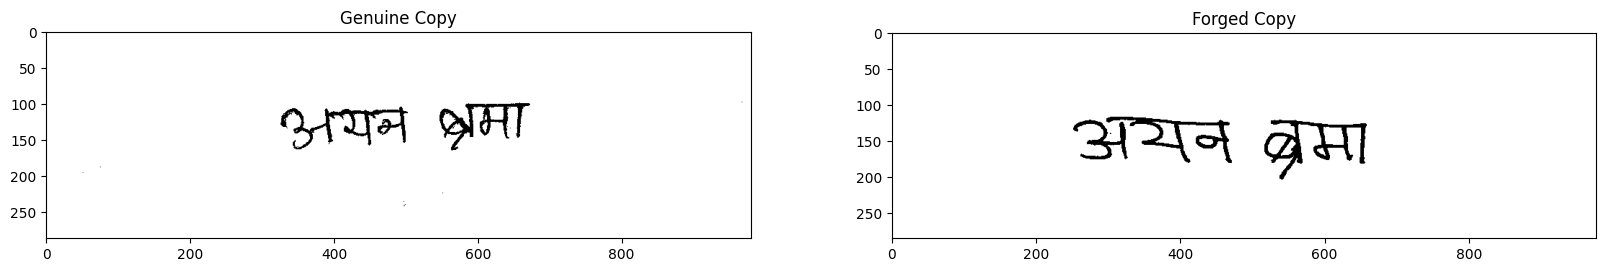

In [ ]:
visualize_sample_signature()

# Building the model:

we will build the siamese model and train it with 3 different types of losses:
- Binary Cross Entropy
- Contrastive loss
- Triplet loss

###Preparing data
Siamese Network has two identical sub-networks, one for the **input image** and other for the **validation image**.

For binary-crossentropy and contrastive loss functions, the dataset should be in the form
- (anchor_image,positive_image,1)
- (anchor_image,negative_image,0)

> Since anchor image and positive image are same, it is similar. So the label is 1

> Anchor image and negative image are dis-similar. So the label is 0


- In our signature verification task, we will construct positive pairs consisting of an anchor signature and an alternative (genuine) signature from the same author.
- We then construct negative pairs composed of an anchor signature and a forged signature authored by a different individual.


Since the anchor images and positive images should be same. We are using the images from **orig_groups_all** which consists of genuine signatures.

In [ ]:
anchor_images = []
for anc in orig_groups_all[:2000]:
  anchor_images.append(anc)

In [ ]:
positive_images = anchor_images.copy()

In [ ]:
len(anchor_images),len(positive_images)

(2000, 2000)

Since the negative images should be different from anchor and positive images. We are using **negative_images** from **forg_groups_all** which contains forg signatures.

In [ ]:
negative_images = []
for anc in forg_groups_all[:2000]:
  negative_images.append(anc)

In [ ]:
len(negative_images)

2000

Creating tf.data() pipeline for positive,negative and anchor images

In [ ]:
import tensorflow as tf
import tensorflow_io as tfio

anchor_dataset = tf.data.Dataset.from_tensor_slices(anchor_images)
positive_dataset = tf.data.Dataset.from_tensor_slices(positive_images)
negative_dataset = tf.data.Dataset.from_tensor_slices(negative_images)

**tf.data.Dataset.zip()** is used for creating dataset by zipping together multiple arrays and tf objects.

In [ ]:
positives = tf.data.Dataset.zip((anchor_dataset,positive_dataset,tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor_images)))))
negatives = tf.data.Dataset.zip((anchor_dataset,negative_dataset,tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor_images)))))
data = positives.concatenate(negatives)

###Preprocessing the data
Let's start preprocessing the Dataset required for **Binary cross entropy** and **contrastive loss**.

In [ ]:
def preprocess_image(filename):

    # Read Image from the file path
    image_string = tf.io.read_file(filename)
    # Decodes a .tiff encoded image tensor of RGBA format (Output shape-[height,width,4])
    image = tfio.experimental.image.decode_tiff(image_string)
    # Selecting only the 3 channels of the image - RGB
    r, g, b = image[:, :, 0], image[:, :, 1], image[:, :, 2]
    # Combines multiple tensors
    image = tf.stack([r,g,b],axis=-1)
    # Resizing the image
    image = tf.image.resize(image, (224,224))
    return image


**preprocess_image()**

- Reads Image
- Converts .tiff to tensor
- resizes the image to size (224,224)

**preprocess_twin**
- Returns **(input_image,validation_image,label)**


Function to preprocess image and return the tuple consisting of

(input_image,validation_image,label)

In [ ]:
# We will use the same preprocess_image() function to preprocess the image

def preprocess_twin(input_img,validation_img,label):

    return (
        preprocess_image(input_img),
        preprocess_image(validation_img),
        label

    )

In [ ]:
example = data.as_numpy_iterator().next()

In [ ]:
len(example)

3

In [ ]:
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=4000)

#### Training and Testing Partition of data

In [ ]:
# Training Partition
train_data = data.take(round(len(data)*.7))
train_data = train_data.batch(32)
train_data = train_data.prefetch(8)

In [ ]:
# Testing partition
test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*0.3))
test_data = test_data.batch(32)
test_data = test_data.prefetch(8)

Now, We have pre-processed the dataset and splitted into training and test partitions.

As we saw above, siamese network is a **twin network** which computes the similarity between the feature embeddings of the two images.


- We will use the  pre-trained model **Resnet50** to train the embeddings to identify similar and dissimilar signatures
- ResNet-50 is a CNN that is 50 layers deep. It has been trained on millions of images from imagenet database and handles vanishing gradient problem in very deep CNNs.

In [ ]:
input_dim = (224,224,3)

In [ ]:
base_cnn = resnet.ResNet50(
    weights="imagenet", input_shape=input_dim, include_top=False
)


flatten = layers.Flatten()(base_cnn.output)
dense1 = layers.Dense(512, activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.001))(flatten)
dense1 = layers.Dropout(0.3)(dense1)
# dense1 = layers.BatchNormalization()(dense1)
dense2 = layers.Dense(256, activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.001))(dense1)
dense2 = layers.Dropout(0.3)(dense2)
# dense2 = layers.BatchNormalization()(dense2)
output = layers.Dense(256)(dense2)

embedding = Model(base_cnn.input, output, name="Embedding")

trainable = False
for layer in base_cnn.layers:
    if layer.name == "conv5_block1_out":
        trainable = True
    layer.trainable = trainable

94765736/94765736 [==============================] - 1s 0us/step


In [ ]:
def euclidean_distance(vects):
    # Compute Euclidean Distance between two vectors
    x, y = vects
    return K.sqrt(K.sum(K.square(x - y), axis=1, keepdims=True))

Function to return shape of euclidean distance layer

In [ ]:
def eucl_dist_output_shape(shapes):
    shape1, shape2 = shapes
    return (shape1[0], 1)

## Building the Siamese Model

In [ ]:
# Building Model for feature extraction
# base_network = build_base_network(input_dim)

# Shape of the Input
img_a = Input(shape=input_dim)
img_b = Input(shape=input_dim)
# label_inp = Input(shape=(1,))

# Extracting embeddings of the image
feat_vecs_a = embedding(resnet.preprocess_input(img_a))
feat_vecs_b = embedding(resnet.preprocess_input(img_b))

# Calculating euclidean distance between the images
distance = Lambda(euclidean_distance,output_shape=eucl_dist_output_shape)([feat_vecs_a, feat_vecs_b])
prediction=Dense(1,activation='sigmoid')(distance)
model = Model([img_a, img_b],prediction)
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 input_3 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 tf.__operators__.getitem (Slic  (None, 224, 224, 3)  0          ['input_2[0][0]']                
 ingOpLambda)                                                                                 

Plotting the architecture of the siamese model

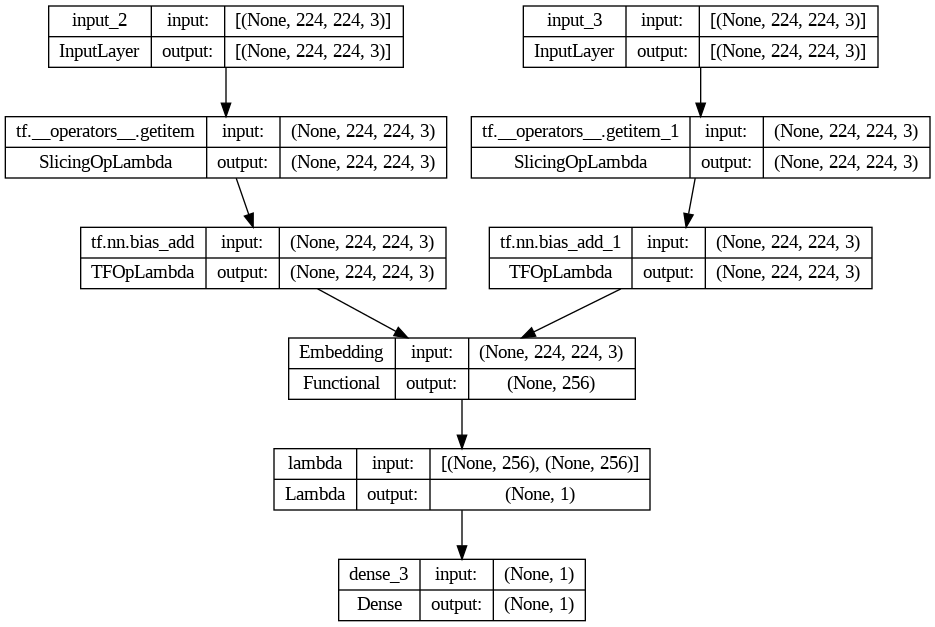

In [ ]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

Creating a directory **Weights_binary** to store the weights of the model at each epoch using **binary_crossentropy** loss function

In [ ]:
!mkdir Weights_binary

Using Adam optimizer

In [ ]:
opt = tf.keras.optimizers.Adam()

### 1. Using **Binary Crossentropy** as loss function

In [ ]:
binary_cross_loss = tf.losses.BinaryCrossentropy()

In [ ]:
!mkdir training_checkpoints

In [ ]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir,'ckpt')
checkpoint = tf.train.Checkpoint(opt=opt,siamese_model = model)

Custom train function to train the model
- Finds loss between predicted and true value
- calculates gradients
- update weights and trains the model

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
acc_metric = tf.keras.metrics.Accuracy()

In [ ]:
EPOCHS=10

In [ ]:
spokglfdv

### Training the model

In [ ]:
for epoch in range(EPOCHS):
  print(f"\nStart of Training Epoch {epoch+1}")
  for idx,batch in enumerate(train_data):
    with tf.GradientTape() as tape:
        y_pred = model(batch[:2],training=True)
        # y_pred = [1 if x>0.5 else 0 for x in y_pred]
        loss = binary_cross_loss(y_pred,batch[2])
    gradients = tape.gradient(loss,model.trainable_weights)
    opt.apply_gradients(zip(gradients,model.trainable_weights))
    acc_metric.update_state(batch[2],y_pred)

  train_acc = acc_metric.result()
  print(f"Accuracy over epoch {train_acc}")
  acc_metric.reset_states()

#### Accuracy on Test data

In [ ]:
from google.colab import files

# Make sure the path to the file is correct.
# If your file is in a folder, include the folder in the path like 'folder_name/my_model.h5'
files.download('/content/path_to_my_model.h5')

In [ ]:
for idx,batch in enumerate(test_data):
  y_pred = model(batch[:2],training=True)
  acc_metric.update_state(y_pred,batch[2])

test_acc=acc_metric.result()
print(f"Accuracy on Test Set is {test_acc}")

In [ ]:
test_input,test_val,y_true = test_data.as_numpy_iterator().next()

In [ ]:
y_hat = model.predict([test_input,test_val])

#### Prediction of a test sample

In [ ]:
y_hat

Setting threshold as 0.5

If the prediction>0.5, then the output is 1 else 0

In [ ]:
y_hat_new = [1 if x>0.5 else 0 for x in y_hat]

#### Predicted y value

In [ ]:
y_hat_new

#### Actual y value

In [ ]:
y_true

### Prediction on Test Image pairs

In [ ]:
for (img1,img2,y) in zip(test_input,test_val,y_true):
  cv2_imshow(img1)
  cv2_imshow(img2)
  pred_val = model.predict([tf.expand_dims(img1,axis=0),tf.expand_dims(img2,axis=0)])[0][0]
  pred_ans = ""
  if pred_val>0.5:
    pred_ans="Genuine"
  else:
    pred_ans='Forged'
  print("Predicted Label: {}".format(pred_ans))
  res = ""
  if y==1:
    res="Genuine"
  else:
    res="Forged"
  print("Actual Label: {}".format(res))
  # print("Cosine Similarity: {}".format(cosine(embedding(tf.expand_dims(img1,axis=0)),embedding(tf.expand_dims(img2,axis=0)))))

Training Accuracy: 66%
Test Accuracy: 70%

#### we will try to improve the accuracy with Contrastive loss

In [ ]:
def contrastive_loss(y_true, y_pred):
    margin = 1
    return K.mean(y_true * K.square(y_pred) + (1 - y_true) * K.square(K.maximum(margin - y_pred, 0)))

In [ ]:
# Building Model for feature extraction
# base_network = build_base_network(input_dim)

# Shape of the Input
img_a = Input(shape=input_dim)
img_b = Input(shape=input_dim)
# label_inp = Input(shape=(1,))

# Extracting embeddings of the image
feat_vecs_a = embedding(resnet.preprocess_input(img_a))
feat_vecs_b = embedding(resnet.preprocess_input(img_b))

# Calculating euclidean distance between the images
distance = Lambda(lambda tensors:K.abs(tensors[0]-tensors[1]))([feat_vecs_a, feat_vecs_b])
prediction=Dense(1,activation='sigmoid')(distance)
model = Model([img_a, img_b],prediction)
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 input_5 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 tf.__operators__.getitem_2 (Sl  (None, 224, 224, 3)  0          ['input_4[0][0]']                
 icingOpLambda)                                                                             

Training the model with **Adam** optimizer and **contrastive** loss using custom train loop

In [ ]:
model.compile(loss=contrastive_loss,optimizer='adam',metrics=['accuracy'])

In [ ]:
EPOCHS=10

Training the model using **Adam** optimizer and **contrastive loss**

In [ ]:
for epoch in range(EPOCHS):
  print(f"\nStart of Training Epoch {epoch}")
  for idx,batch in enumerate(train_data):
    with tf.GradientTape() as tape:
        y_pred = model(batch[:2],training=True)
        # y_pred = [1 if x>0.5 else 0 for x in y_pred]
        loss = contrastive_loss(y_pred,batch[2])
    gradients = tape.gradient(loss,model.trainable_weights)
    opt.apply_gradients(zip(gradients,model.trainable_weights))
    acc_metric.update_state(batch[2],y_pred)

  train_acc = acc_metric.result()
  print(f"Accuracy over epoch {train_acc}")
  acc_metric.reset_states()

Accuracy on Test Data

In [ ]:
for idx,batch in enumerate(test_data):
  y_pred = model(batch[:2],training=True)
  acc_metric.update_state(y_pred,batch[2])

test_acc=acc_metric.result()
print(f"Accuracy on Test Set is {test_acc}")

Accuracy on Test Set is 0.49416667222976685


In [ ]:
test_input,test_val,y_true = test_data.as_numpy_iterator().next()

In [ ]:
y_hat = model.predict([test_input,test_val])

1/1 [==============================] - 4s 4s/step


Predicted y value

In [ ]:
y_hat

array([[0.5000993],
       [0.5000993],
       [1.       ],
       [1.       ],
       [0.9994689],
       [1.       ],
       [0.5000993],
       [1.       ],
       [0.5000993],
       [1.       ],
       [1.       ],
       [0.5000993],
       [0.5000993],
       [1.       ],
       [0.5000993],
       [0.5000993],
       [1.       ],
       [1.       ],
       [0.5000993],
       [0.5000993],
       [0.5000993],
       [1.       ],
       [1.       ],
       [0.5000993],
       [0.5000993],
       [1.       ],
       [0.5000993],
       [0.5000993],
       [0.5000993],
       [0.5000993],
       [0.5000993],
       [1.       ]], dtype=float32)

### Prediction on Test image pairs

In [ ]:
for (img1,img2,y) in zip(test_input,test_val,y_true):
  cv2_imshow(img1)
  cv2_imshow(img2)
  pred_val = model.predict([tf.expand_dims(img1,axis=0),tf.expand_dims(img2,axis=0)])[0][0]
  pred_ans = ""
  if pred_val>0.5:
    pred_ans="Genuine"
  else:
    pred_ans='Forged'
  print("Predicted Label: {}".format(pred_ans))
  res = ""
  if y==1:
    res="Genuine"
  else:
    res="Forged"
  print("Actual Label: {}".format(res))
  # print("Cosine Similarity: {}".format(cosine(embedding(tf.expand_dims(img1,axis=0)),embedding(tf.expand_dims(img2,axis=0)))))

**Triplet Loss** is defined as

> $L(A,P,N)=max(0,d(A,P)-d(A,N)+\alpha)$

Now, we will implement triplet loss

In [ ]:
def triplet_loss(y_true, y_pred):
    # Initialize alpha value
    alpha = 0.5
    # Getting anchor, positive and negative embeddings
    anchor, positive, negative =y_pred[0,0:512], y_pred[0,512:1024], y_pred[0,1024:1536]
    # Calculating distance between anchor and positive
    positive_distance = K.mean(K.square(anchor - positive),axis=-1)
    # Calculating distance between anchor and negative
    negative_distance = K.mean(K.square(anchor - negative),axis=-1)
    # Implement the formula
    return K.mean(K.maximum(0.0, positive_distance - negative_distance + alpha))

As you can see below, the positive and anchor image are same but the negative image is different. That's what we want

In [ ]:
anchor_images[500]

'./signatures/BHSig260/Hindi/021/H-S-21-G-21.tif'

In [ ]:
positive_images[500]

'./signatures/BHSig260/Hindi/021/H-S-21-G-21.tif'

In [ ]:
negative_images[500]

'./signatures/BHSig260/Hindi/021/H-S-21-F-21.tif'

Displaying a sample of anchor, positive and negative image

In [ ]:
img1 = mpimg.imread(anchor_images[1999])
img2 = mpimg.imread(positive_images[1999])
img3 = mpimg.imread(negative_images[1999])

Anchor Image

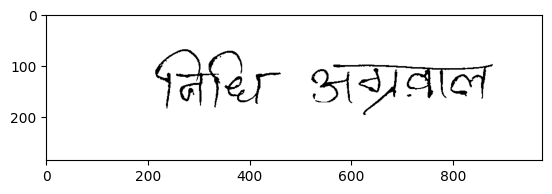

In [ ]:
plt.imshow(img1)

Positive Image

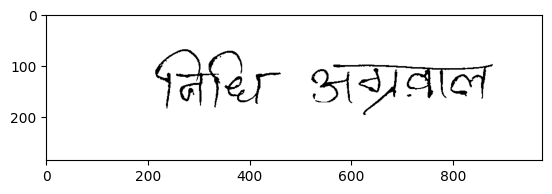

In [ ]:
plt.imshow(img2)

Negative Image

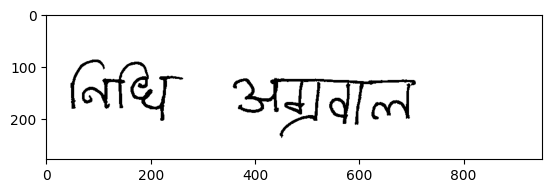

In [ ]:
plt.imshow(img3)

**tf.data.Dataset.zip()** is used for creating dataset by zipping together multiple arrays and tf objects.

In [ ]:
dataset = tf.data.Dataset.zip((anchor_dataset,positive_dataset,negative_dataset))

**preprocess_image()** - Load the specified file as a JPEG image, preprocess it and resize it to the target shape.

**preprocess_triplets** - Preprocess the image and return as a triplet

In [ ]:
def preprocess_triplets(anchor, positive, negative):

    return (
        preprocess_image(anchor),
        preprocess_image(positive),
        preprocess_image(negative),
    )

Sample triplet of anchor,positve,negative

In [ ]:
sample = dataset.as_numpy_iterator().next()

In [ ]:
sample

(b'./signatures/BHSig260/Hindi/001/H-S-1-G-01.tif',
 b'./signatures/BHSig260/Hindi/001/H-S-1-G-01.tif',
 b'./signatures/BHSig260/Hindi/001/H-S-1-F-01.tif')

- **.shuffle()** - shuffles the samples in the dataset.

- **.map()** - transforms items in the dataset

In [ ]:
dataset = dataset.shuffle(buffer_size=1024)
dataset = dataset.map(preprocess_triplets)

In [ ]:
image_count = len(anchor_images)

Taking 80% of dataset as training and remaining 20% for validation

In [ ]:
train_dataset = dataset.take(round(image_count * 0.8))
val_dataset = dataset.skip(round(image_count * 0.8))

train_dataset = train_dataset.batch(32, drop_remainder=False)
train_dataset = train_dataset.prefetch(8)

val_dataset = val_dataset.batch(32, drop_remainder=False)
val_dataset = val_dataset.prefetch(8)

**Visualize a few triplets from the supplied batches.**

In [ ]:
def visualize(anchor, positive, negative):

    def show(ax, image):
        ax.imshow(image)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    fig = plt.figure(figsize=(9, 9))

    axs = fig.subplots(3, 3)
    for i in range(3):
        show(axs[i, 0], np.clip(anchor[i],0,1))
        show(axs[i, 1], np.clip(positive[i],0,1))
        show(axs[i, 2], np.clip(negative[i],0,1))


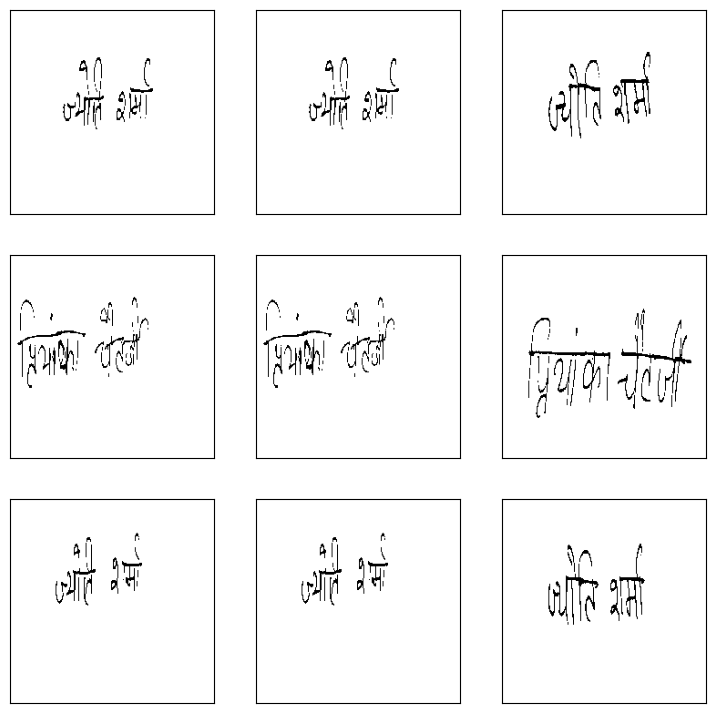

In [ ]:
visualize(*list(train_dataset.take(1).as_numpy_iterator())[0])

In [ ]:
target_shape=(224,224)

In [ ]:
# VGG19 Model
base_cnn = applications.vgg19.VGG19(weights='imagenet', include_top=False,input_shape=(224,224,3),pooling='max')
for layer in base_cnn.layers[:15]:
    layer.trainable = False

flatten = layers.Flatten()(base_cnn.output)
dense1 = layers.Dense(512, activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.001))(flatten)
dense1 = layers.Dropout(0.3)(dense1)
dense2 = layers.Dense(256, activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.001))(dense1)
dense2 = layers.Dropout(0.2)(dense2)
output = layers.Dense(256)(dense2)

embedding = Model(base_cnn.input, output, name="Embedding")


# Inputs for Anchor, positive and negative images
anchor_in = Input(name='anchor',shape=target_shape+(3,))
pos_in = Input(name='positive',shape=target_shape+(3,))
neg_in = Input(name='negative',shape=target_shape+(3,))

# Extract embeddings using VGG19
anchor_out = embedding(anchor_in)
pos_out = embedding(pos_in)
neg_out = embedding(neg_in)
# Concatenate the embeddings
merged_vector = concatenate([anchor_out, pos_out, neg_out],axis=1)

# Define the model
model_triplet_loss = Model(inputs=[anchor_in, pos_in, neg_in], outputs=merged_vector)

# Compiling the model using Adam optimizer and triplet loss
model_triplet_loss.compile(optimizer=Adam(lr=0.0001),loss=tfa.losses.TripletHardLoss())


80134624/80134624 [==============================] - 0s 0us/step


In [ ]:
for i in range(10):
  model_triplet_loss.fit(next(iter(train_dataset)),np.ones(shape=32),validation_data=(next(iter(val_dataset)),np.ones(shape=32)),epochs=5,steps_per_epoch=30)

def triplet_accuracy(y_true, y_pred):
    # Assuming y_pred is the concatenated output of [anchor_out, pos_out, neg_out]
    anchor, positive, negative = y_pred[:, :256], y_pred[:, 256:512], y_pred[:, 512:]

    # Compute the Euclidean distance between anchor and positive
    pos_dist = K.sqrt(K.sum(K.square(anchor - positive), axis=1))
    # Compute the Euclidean distance between anchor and negative
    neg_dist = K.sqrt(K.sum(K.square(anchor - negative), axis=1))

    # A correct prediction is when pos_dist is less than neg_dist
    return K.mean(pos_dist < neg_dist)

# Update your model compilation to include the custom metric
model_triplet_loss.compile(optimizer=tf.keras.optimizers.Adam(lr=0.0001),
                           loss=tfa.losses.TripletHardLoss(),
                           metrics=[triplet_accuracy])

# Continue with training as usual
history = model_triplet_loss.fit(next(iter(train_dataset)), np.ones(shape=32),
                                 validation_data=(next(iter(val_dataset)), np.ones(shape=32)),
                                 epochs=5, steps_per_epoch=30)

# To display the accuracy for each epoch, you can use the history object
for epoch, acc in enumerate(history.history['triplet_accuracy']):
    print(f"Epoch {epoch + 1}: Accuracy = {acc:.4f}")

Epoch 1/5
30/30 [==============================] - 56s 2s/step - loss: 1.0065 - triplet_accuracy: 0.7833 - val_loss: 1.0050 - val_triplet_accuracy: 1.0000
Epoch 2/5
30/30 [==============================] - 53s 2s/step - loss: 1.0041 - triplet_accuracy: 0.8667 - val_loss: 1.0032 - val_triplet_accuracy: 1.0000
Epoch 3/5
20/30 [===================>..........] - ETA: 12s - loss: 1.0027 - triplet_accuracy: 0.9250

30/30 [==============================] - 41s 1s/step - loss: 1.0027 - triplet_accuracy: 0.9250 - val_loss: 1.0023 - val_triplet_accuracy: 1.0000
Epoch 1/5
30/30 [==============================] - 53s 2s/step - loss: 1.0019 - triplet_accuracy: 0.9500 - val_loss: 1.0014 - val_triplet_accuracy: 1.0000
Epoch 2/5
30/30 [==============================] - 53s 2s/step - loss: 1.0011 - triplet_accuracy: 0.9667 - val_loss: 1.0009 - val_triplet_accuracy: 1.0000
Epoch 3/5
20/30 [===================>..........] - ETA: 12s - loss: 1.0008 - triplet_accuracy: 0.9250

30/30 [==============================] - 40s 1s/step - loss: 1.0008 - triplet_accuracy: 0.9250 - val_loss: 1.0006 - val_triplet_accuracy: 1.0000
Epoch 1/5
30/30 [==============================] - 53s 2s/step - loss: 1.0005 - triplet_accuracy: 0.9000 - val_loss: 1.0004 - val_triplet_accuracy: 1.0000
Epoch 2/5
30/30 [==============================] - 53s 2s/step - loss: 1.0003 - triplet_accuracy: 0.9333 - val_loss: 1.0002 - val_triplet_accuracy: 1.0000
Epoch 3/5
20/30 [===================>..........] - ETA: 13s - loss: 1.0002 - triplet_accuracy: 0.9000

30/30 [==============================] - 41s 1s/step - loss: 1.0002 - triplet_accuracy: 0.9000 - val_loss: 1.0002 - val_triplet_accuracy: 1.0000
Epoch 1/5
30/30 [==============================] - 53s 2s/step - loss: 1.0001 - triplet_accuracy: 0.8833 - val_loss: 1.0001 - val_triplet_accuracy: 1.0000
Epoch 2/5
30/30 [==============================] - 53s 2s/step - loss: 1.0001 - triplet_accuracy: 0.9000 - val_loss: 1.0001 - val_triplet_accuracy: 1.0000
Epoch 3/5
20/30 [===================>..........] - ETA: 12s - loss: 1.0000 - triplet_accuracy: 0.9250

30/30 [==============================] - 40s 1s/step - loss: 1.0000 - triplet_accuracy: 0.9250 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 1/5
30/30 [==============================] - 53s 2s/step - loss: 1.0000 - triplet_accuracy: 0.9000 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 2/5
30/30 [==============================] - 53s 2s/step - loss: 1.0000 - triplet_accuracy: 0.9167 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 3/5
20/30 [===================>..........] - ETA: 12s - loss: 1.0000 - triplet_accuracy: 0.9000

...

30/30 [==============================] - 40s 1s/step - loss: 1.0000 - triplet_accuracy: 0.9000 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 1/5
30/30 [==============================] - 53s 2s/step - loss: 1.0000 - triplet_accuracy: 0.9167 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 2/5
30/30 [==============================] - 52s 2s/step - loss: 1.0000 - triplet_accuracy: 0.8500 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 3/5
20/30 [===================>..........] - ETA: 12s - loss: 1.0000 - triplet_accuracy: 0.9250

30/30 [==============================] - 40s 1s/step - loss: 1.0000 - triplet_accuracy: 0.9250 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 1/5
30/30 [==============================] - 53s 2s/step - loss: 1.0000 - triplet_accuracy: 0.7500 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 2/5
30/30 [==============================] - 53s 2s/step - loss: 1.0000 - triplet_accuracy: 0.9500 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 3/5
20/30 [===================>..........] - ETA: 12s - loss: 1.0000 - triplet_accuracy: 0.8500

30/30 [==============================] - 40s 1s/step - loss: 1.0000 - triplet_accuracy: 0.8500 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 1/5
30/30 [==============================] - 53s 2s/step - loss: 1.0000 - triplet_accuracy: 0.8667 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 2/5
30/30 [==============================] - 53s 2s/step - loss: 1.0000 - triplet_accuracy: 0.8333 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 3/5
20/30 [===================>..........] - ETA: 12s - loss: 1.0000 - triplet_accuracy: 0.8750

30/30 [==============================] - 40s 1s/step - loss: 1.0000 - triplet_accuracy: 0.8750 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 1/5
30/30 [==============================] - 57s 2s/step - loss: 1.0000 - triplet_accuracy: 0.8333 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 2/5
30/30 [==============================] - 54s 2s/step - loss: 1.0000 - triplet_accuracy: 0.8167 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 3/5
20/30 [===================>..........] - ETA: 13s - loss: 1.0000 - triplet_accuracy: 0.7250

30/30 [==============================] - 41s 1s/step - loss: 1.0000 - triplet_accuracy: 0.7250 - val_loss: 1.0000 - val_triplet_accuracy: 1.0000
Epoch 1: Accuracy = 0.8333
Epoch 2: Accuracy = 0.8167
Epoch 3: Accuracy = 0.7250


In [ ]:
cosine = metrics.CosineSimilarity()

In [ ]:
for i in range(5):
  sample = next(iter(val_dataset))
  # print(siamese_model.predict(sample))
  anchor, positive, negative = sample
  anchor_embedding, positive_embedding, negative_embedding = (
    embedding(anchor),embedding(positive),embedding(negative)
)
  print("Positive Similarity: {}".format(cosine(anchor_embedding,positive_embedding)))
  print("Negative Similarity: {}".format(cosine(anchor_embedding,negative_embedding)))

  print()

Positive Similarity: 3.458026234672217e-17
Negative Similarity: 3.37812687407225e-17

Positive Similarity: 3.458879223319882e-17
Negative Similarity: 3.462241216201542e-17

Positive Similarity: 3.461443483218796e-17
Negative Similarity: 3.4303322277639417e-17

Positive Similarity: 3.455843470471812e-17
Negative Similarity: 3.434451918086701e-17

Positive Similarity: 3.4828330503704373e-17
Negative Similarity: 3.4811654542555304e-17



In [ ]:
results = []
for i in range(5):
  sample = next(iter(train_dataset))
  res = model_triplet_loss.predict(sample)
  results.append(res[0])
  results.append(res[0])
  results.append(res[0])
  results.append(res[0])

1/1 [==============================] - 15s 15s/step


In [ ]:
# Save test embeddings for visualization in projector
np.savetxt("vecs.tsv", results, delimiter='\t')

<img src="https://drive.google.com/uc?id=1jNb2UnJsWoTcpP_nYXVMoVes9__s1FaP" width=600>

So Lets change the activation function to sigmoid in the last layer of the embeddings

In [ ]:
# VGG19 Model
base_cnn = applications.vgg19.VGG19(weights='imagenet', include_top=False,input_shape=(224,224,3),pooling='max')
for layer in base_cnn.layers[:15]:
    layer.trainable = False

flatten = layers.Flatten()(base_cnn.output)
dense1 = layers.Dense(128, activation="relu")(flatten)
dense2 = layers.Dropout(0.3)(dense1)
output = layers.Dense(512,activation='sigmoid')(dense2)

embedding = Model(base_cnn.input, output, name="Embedding")


# Inputs for Anchor, positive and negative images
anchor_in = Input(name='anchor',shape=target_shape+(3,))
pos_in = Input(name='positive',shape=target_shape+(3,))
neg_in = Input(name='negative',shape=target_shape+(3,))

# Extract embeddings using VGG19
anchor_out = embedding(anchor_in)
pos_out = embedding(pos_in)
neg_out = embedding(neg_in)
# Concatenate the embeddings
merged_vector = concatenate([anchor_out, pos_out, neg_out],axis=1)

# Define the model
model_lossless_triplet_loss = Model(inputs=[anchor_in, pos_in, neg_in], outputs=merged_vector)

In [ ]:
# Custom Function for lossless triplet loss
def lossless_triplet_loss(y_true, y_pred, beta=3, epsilon=1e-8):
    anchor, positive, negative =y_pred[0,0:512], y_pred[0,512:1024], y_pred[0,1024:1536]

    pos_dist = K.mean(K.square(anchor - positive),axis=-1)
    neg_dist = K.mean(K.square(anchor - negative),axis=-1)

    N=3
    pos_dist = -tf.math.log(-tf.divide((pos_dist),beta)+1+epsilon)
    neg_dist = -tf.math.log(-tf.divide((N-neg_dist),beta)+1+epsilon)
    loss = neg_dist + pos_dist

    return loss

In [ ]:
# Compiling the model using Adam optimizer and lossless triplet loss
model_lossless_triplet_loss.compile(optimizer=Adam(lr=0.00001),loss=lossless_triplet_loss)

In [ ]:
target_shape=(224,224)

In [ ]:
for i in range(10):
  model_lossless_triplet_loss.fit(next(iter(train_dataset)),np.ones(shape=32),validation_data=(next(iter(val_dataset)),np.ones(shape=32)),epochs=5,steps_per_epoch=30)

Epoch 1/5
30/30 [==============================] - 39s 1s/step - loss: 2.5020 - val_loss: 2.9951
Epoch 2/5
30/30 [==============================] - 37s 1s/step - loss: 2.3596 - val_loss: 2.8594
Epoch 3/5
20/30 [===================>..........] - ETA: 8s - loss: 2.2609

30/30 [==============================] - 27s 912ms/step - loss: 2.2609 - val_loss: 2.7776
Epoch 1/5
30/30 [==============================] - 37s 1s/step - loss: 2.3181 - val_loss: 2.6529
Epoch 2/5
30/30 [==============================] - 36s 1s/step - loss: 2.1854 - val_loss: 2.7083
Epoch 3/5
20/30 [===================>..........] - ETA: 8s - loss: 2.1164

30/30 [==============================] - 28s 918ms/step - loss: 2.1164 - val_loss: 2.7069
Epoch 1/5
30/30 [==============================] - 38s 1s/step - loss: 2.1384 - val_loss: 2.0859
Epoch 2/5
30/30 [==============================] - 37s 1s/step - loss: 1.9916 - val_loss: 2.0025
Epoch 3/5
20/30 [===================>..........] - ETA: 8s - loss: 1.9796

30/30 [==============================] - 27s 912ms/step - loss: 1.9796 - val_loss: 1.9370
Epoch 1/5
30/30 [==============================] - 37s 1s/step - loss: 2.1341 - val_loss: 2.4616
Epoch 2/5
30/30 [==============================] - 36s 1s/step - loss: 2.0925 - val_loss: 2.5419
Epoch 3/5
20/30 [===================>..........] - ETA: 9s - loss: 1.9768

30/30 [==============================] - 28s 922ms/step - loss: 1.9768 - val_loss: 2.5913
Epoch 1/5
30/30 [==============================] - 36s 1s/step - loss: 2.1163 - val_loss: 2.1566
Epoch 2/5
30/30 [==============================] - 36s 1s/step - loss: 2.0535 - val_loss: 2.0946
Epoch 3/5
20/30 [===================>..........] - ETA: 8s - loss: 1.9147

...

30/30 [==============================] - 27s 914ms/step - loss: 1.8271 - val_loss: 1.6902
Epoch 1/5
30/30 [==============================] - 35s 1s/step - loss: 2.0967 - val_loss: 1.6586
Epoch 2/5
30/30 [==============================] - 36s 1s/step - loss: 1.9374 - val_loss: 1.6364
Epoch 3/5
20/30 [===================>..........] - ETA: 8s - loss: 1.8906

30/30 [==============================] - 27s 910ms/step - loss: 1.8906 - val_loss: 1.6080
Epoch 1/5
30/30 [==============================] - 36s 1s/step - loss: 1.9098 - val_loss: 1.9851
Epoch 2/5
30/30 [==============================] - 36s 1s/step - loss: 1.8786 - val_loss: 1.8379
Epoch 3/5
20/30 [===================>..........] - ETA: 8s - loss: 1.9400

30/30 [==============================] - 27s 908ms/step - loss: 1.9400 - val_loss: 1.6922
Epoch 1/5
30/30 [==============================] - 36s 1s/step - loss: 1.8573 - val_loss: 1.5286
Epoch 2/5
30/30 [==============================] - 35s 1s/step - loss: 1.7767 - val_loss: 1.5394
Epoch 3/5
20/30 [===================>..........] - ETA: 8s - loss: 1.7548

30/30 [==============================] - 27s 895ms/step - loss: 1.7548 - val_loss: 1.5137
Epoch 1/5
30/30 [==============================] - 35s 1s/step - loss: 1.8884 - val_loss: 1.6012
Epoch 2/5
30/30 [==============================] - 36s 1s/step - loss: 1.8530 - val_loss: 1.6399
Epoch 3/5
20/30 [===================>..........] - ETA: 8s - loss: 1.7976

30/30 [==============================] - 27s 900ms/step - loss: 1.7976 - val_loss: 1.6013


In [ ]:
for i in range(5):
  sample = next(iter(val_dataset))
  # print(siamese_model.predict(sample))
  anchor, positive, negative = sample
  anchor_embedding, positive_embedding, negative_embedding = (
    embedding(anchor),embedding(positive),embedding(negative)
)

  print("Positive Similarity: {}".format(cosine(anchor_embedding,positive_embedding)))
  print("Negative Similarity: {}".format(cosine(anchor_embedding,negative_embedding)))
  print()

Positive Similarity: 0.9142277240753174
Negative Similarity: 0.8837229609489441

Positive Similarity: 0.8926673531532288
Negative Similarity: 0.8641859889030457

Positive Similarity: 0.8732402920722961
Negative Similarity: 0.8514592051506042

Positive Similarity: 0.8601968884468079
Negative Similarity: 0.8447601199150085

Positive Similarity: 0.8529305458068848
Negative Similarity: 0.8320509791374207



In [ ]:
from google.colab import files

model_lossless_triplet_loss.save('/content/triplet_loss.h5')

# Make sure the path to the file is correct.
# If your file is in a folder, include the folder in the path like 'folder_name/my_model.h5'
files.download('/content/triplet_loss.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Conclusion**

- As we can see above, when the model is trained with triplet loss and lossless triplet loss, the embeddings learn to differentiate between the similar images and dis-similar images clearly.

- Lossless triplet loss is better than the standard triplet loss because:
 - In **Standard triplet loss**, if loss value becomes negative then, it'll be zero, which is a clear lost of information
 - In **lossless triplet loss**, the non-linearity is introduced which makes it really costly as more the error grows.

- So, we can say that **Lossless Triplet Loss** is the best loss function for pairwise learning which can be used in siamese network for best performance.


## Summary

- A **Siamese neural network** is an artificial neural network that contains two or more identical subnetwork which is also known as twin neural network or sister network.

- Siamese network takes two different inputs passed through two similar subnetworks with the same architecture, parameters, and weights.

- Siamese network’s objective is to classify if the two inputs are the same or different using the Similarity score.

- The Similarity score can be calculated using **Binary cross-entropy**, **Contrastive function**, or **Triplet loss**, which are techniques for the general distance metric learning approach.

- Since training of Siamese networks involves pairwise learning usual, Cross entropy loss cannot be used in this case, mainly two loss functions are used, they are
 - **Contrastive loss**
 - **Triplet loss**

- **Contrastive loss** is a metric learning objective function where we learn from training data examples structured as pairs:
 - Positive pairs (examples that belong to the same class)
 - Negative pairs (examples that belong to different classes).

- The contrastive loss function is set up such that we minimize the distance between embeddings for positive pairs, and maximize the distance between embeddings for negative pairs.

- The **triplet loss** function is an alternative to the contrastive loss function. It has convergence advantages over contrastive loss function

- The distance between the baseline input and the positive input is reduced to a minimum, while the distance between the baseline input and the negative input is increased.

- The triplet loss function aims to learn a distance between representations such that the anchor-to-positive distance is less than the anchor-to-negative distance.